In [1]:
import numpy as np
import moments 
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
from matplotlib.transforms import ScaledTranslation

In [2]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5

lw = 1

In [3]:
def size_change_var(tau, nu):
    """
    compute Var(T) / E[T]^2 following size change
    :param tau: time since change in units of 2Na
    :param nu: ratio of N1 / Na
    """
    ret = (
        (2 * np.exp(tau / nu)
        * (tau + nu ** 2 * np.exp(tau / nu) - nu * (tau + nu) + 1))
        / (nu * (np.exp(tau / nu) - 1) + 1) ** 2 - 1
    ) 
    return ret

In [4]:
def make_growth_plot(ax):
    tmax = 10
    xx = np.linspace(0, tmax, 101)
    # nu 2
    yy = size_change_var(xx, 2)
    ax.plot(xx, yy, color="tab:blue", lw=lw, label=r"$\nu=2$")

    # nu 5
    yy = size_change_var(xx, 5)
    ax.plot(xx, yy, color="tab:orange", lw=lw, label=r"$\nu=5$")

    # nu 10
    yy = size_change_var(xx, 10)
    ax.plot(xx, yy, color="tab:green", lw=lw, label=r"$\nu=10$")

    ax.set_ylim(0, )
    ax.set_xlim(0, tmax)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\operatorname{Var}(T)/\mathbb{E}[T]^2$")
    ax.legend(framealpha=0, ncols=3)
    return

In [5]:
def make_shrinkage_plot(ax):
    tmax = 2
    xx = np.linspace(0, tmax, 101)
    # nu 10
    yy = size_change_var(xx, 0.1)
    ax.plot(xx, yy, color="tab:blue", lw=lw, label=r"$\nu=0.1$")

    # nu 5
    yy = size_change_var(xx, 0.2)
    ax.plot(xx, yy, color="tab:orange", lw=lw, label=r"$\nu=0.2$")

    # nu 2
    yy = size_change_var(xx, 0.5)
    ax.plot(xx, yy, color="tab:green", lw=lw, label=r"$\nu=0.5$")

    ax.set_ylim(0, )
    ax.set_xlim(0, tmax)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\operatorname{Var}(T)/\mathbb{E}[T]^2$")
    ax.legend(framealpha=0)
    ax.set_xticks([0, 1, 2])
    return

In [6]:
def divergence_var(tau):
    """
    compute Var(T) / E[T]^2 following population divergence and isolation
    when one allele is sampled from each population
    :param tau: time since divergence in units 2Na
    """
    ret = 1 / (tau ** 2 + 2 * tau + 1)
    return ret

In [7]:
def make_divergence_plot(ax):
    tmax = 5
    xx = np.linspace(0, tmax, 201)

    yy = divergence_var(xx)
    ax.plot(xx, yy, color="black", lw=lw)

    ax.set_ylim(0, )
    ax.set_xlim(0, tmax)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\operatorname{Var}(T)/\mathbb{E}[T]^2$")
    return

In [8]:
def island_w_var(M):
    """
    Scaled variance within in the island model
    """
    ret = 1 + 1 / (2 * M)
    return ret


def island_b_var(M):
    """
    Scaled variance between in the island model
    """
    ret = (1 + 2 * M + 4 * M ** 2) / (1 + 4 * M + 4 * M**2)
    return ret


def make_island_plot(ax):
    xx = np.logspace(-2, 3, 201)

    ax.hlines(1, 0, 1000, color="black", linestyles="dashed", lw=0.5)

    yy = island_w_var(xx)
    ax.plot(xx, yy, color="tab:blue", lw=lw, label="within")

    yy = island_b_var(xx)
    ax.plot(xx, yy, color="tab:orange", lw=lw, label="between")

    #ax.set_ylim(0, )
    ax.set_xlim(1e-2, 1000)
    ax.set_xlabel(r"$M$")
    ax.set_ylabel(r"$\operatorname{Var}(T)/\mathbb{E}[T]^2$")
    ax.legend(framealpha=0, ncols=2)
    ax.set_yscale("log")
    ax.set_xscale("log")
    return

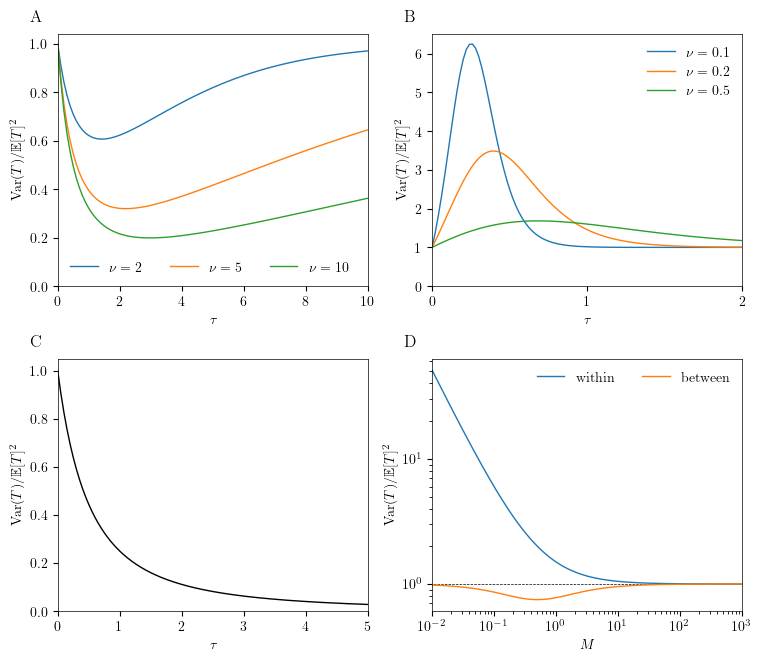

In [9]:
mosaic = "AB;CD"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 6.5), layout="constrained")
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
make_growth_plot(axs["A"])
make_shrinkage_plot(axs["B"])
make_divergence_plot(axs["C"])
make_island_plot(axs["D"])
plt.savefig("figures/figA2.pdf")

In [10]:
# checking to make sure I understand how moments defines M
M = 1e-3
M2 = M / 2
# moments uses 2Nm, M=4Nm
moments_result = moments.LD.Demographics2D.island_model([1, 1, M2, M2], theta=1).H()
print(moments_result)
analytic_result = [
    2, 
    2 + 1 / M,
    2
]
print(analytic_result)

[   2. 1002.    2.]
[2, 1002.0, 2]


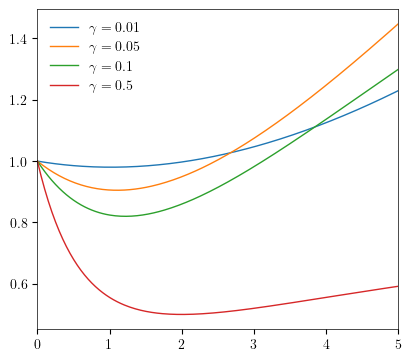

In [20]:
# introgression

def plot_introg(ax):

    sclvar = lambda t, g: ((1 - 2 * (-1 + g) * g * (1 + 2 * (-1 + g) * g) * t**2)
        / (1 - 2 * (-1 + g) * g * t) ** 2)

    xx = np.linspace(0, 5, 200)
    ax.plot(xx, sclvar(xx, 0.01), color="tab:blue", lw=lw, label=r"$\gamma = 0.01$")
    ax.plot(xx, sclvar(xx, 0.05), color="tab:orange", lw=lw, label=r"$\gamma = 0.05$")
    ax.plot(xx, sclvar(xx, 0.1), color="tab:green", lw=lw, label=r"$\gamma = 0.1$")
    ax.plot(xx, sclvar(xx, 0.5), color="tab:red", lw=lw, label=r"$\gamma = 0.5$")

    ax.legend(framealpha=0)
    ax.set_xlim(xx[0], xx[-1])
    return


mosaic = "A"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(4, 3.5), layout="constrained")
plot_introg(axs["A"])

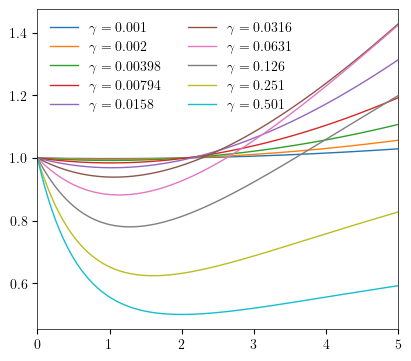

In [33]:
# introgression

def plot_introg(ax):

    sclvar = lambda t, g: ((1 - 2 * (-1 + g) * g * (1 + 2 * (-1 + g) * g) * t**2)
        / (1 - 2 * (-1 + g) * g * t) ** 2)

    xx = np.linspace(0, 5, 200)
    for gamma in np.logspace(-3, -0.3, 10):
        ax.plot(xx, sclvar(xx, gamma), lw=lw, label=rf"$\gamma = {gamma:.3}$")

    ax.legend(framealpha=0, ncols=2)
    ax.set_xlim(xx[0], xx[-1])
    return


mosaic = "A"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(4, 3.5), layout="constrained")
plot_introg(axs["A"])

In [16]:
def plot_equil_hr_stats(ax):
    N = 1e4
    u = 1e-8
    theta = 4 * N * u
    rr = np.logspace(-6, -2, 101)
    rhos = rr * 4 * N 
    yy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)

    ax.plot(rhos, yy.H2(0), color="black", label=r"$\mathbb{E}[D^+]$", lw=lw)

    DD = yy.LD()[:, 0]
    Dz = yy.LD()[:, 1]
    pi2 = yy.LD()[:, 2]
    ax.plot(rhos, 4 * pi2, color="tab:blue", lw=lw, label=r"$4\mathbb{E}[\pi_2]$")
    ax.plot(rhos, 4 * DD, color="tab:orange", lw=lw, label=r"$4\mathbb{E}[D^2]$")
    ax.plot(rhos, 2 * Dz, color="tab:green", lw=lw, label=r"$2\mathbb{E}[Dz]$")

    ax.set_xscale("log")
    ax.set_ylim(0, )
    ax.set_ylabel("statistic")
    ax.set_xlabel(r"$\rho$")
    ax.legend(framealpha=0)
    ax.set_yticks([0, theta ** 2, 2 * theta ** 2], [0, r"$\theta^2$", r"$2\theta^2$"])
    return

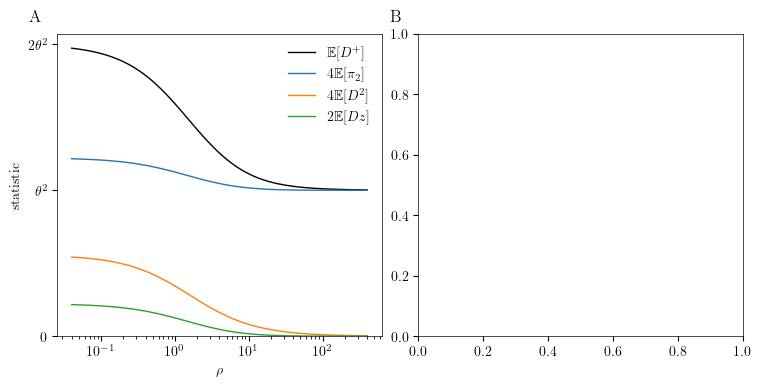

In [17]:
mosaic = "AB"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 3.75), layout="constrained")
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
plot_equil_hr_stats(axs["A"])
plt.savefig("figures/figA1.pdf")

In [13]:
N = 1e4
u = 1e-8
theta = 4 * N * u
rr = np.logspace(-6, -2, 101)
rhos = rr * 4 * N 
yy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)

In [14]:
yy.names()

(['DD_0_0', 'Dz_0_0_0', 'pi2_0_0_0_0'], ['H_0_0'])

In [15]:
yy.LD()[:, 0]

array([2.16827920e-08, 2.16321543e-08, 2.15769070e-08, 2.15166586e-08,
       2.14509898e-08, 2.13794526e-08, 2.13015696e-08, 2.12168336e-08,
       2.11247074e-08, 2.10246243e-08, 2.09159888e-08, 2.07981781e-08,
       2.06705440e-08, 2.05324161e-08, 2.03831057e-08, 2.02219104e-08,
       2.00481203e-08, 1.98610255e-08, 1.96599246e-08, 1.94441347e-08,
       1.92130033e-08, 1.89659206e-08, 1.87023344e-08, 1.84217648e-08,
       1.81238213e-08, 1.78082192e-08, 1.74747969e-08, 1.71235328e-08,
       1.67545613e-08, 1.63681872e-08, 1.59648974e-08, 1.55453705e-08,
       1.51104822e-08, 1.46613057e-08, 1.41991087e-08, 1.37253438e-08,
       1.32416345e-08, 1.27497556e-08, 1.22516088e-08, 1.17491939e-08,
       1.12445771e-08, 1.07398568e-08, 1.02371278e-08, 9.73844680e-09,
       9.24579816e-09, 8.76106305e-09, 8.28599186e-09, 7.82218117e-09,
       7.37105568e-09, 6.93385534e-09, 6.51162791e-09, 6.10522655e-09,
       5.71531215e-09, 5.34235972e-09, 4.98666841e-09, 4.64837407e-09,
      